# Assignment 1 - Customer Churn Prediction

## Business objective
The telecom company wants to identify customers who are likely to churn so the retention team can intervene before the customer leaves. The model therefore needs to identify the churn class reliably while so the rentention team can proactively engage with them.

Workflow: data understanding → cleaning → leakage-safe 70:30 split → EDA → feature engineering → two Decision Tree configurations → evaluation → interpretation → saved pipeline.

## 1. Imports and project paths
The notebook uses the supplied `TelcoCustomerChurn.csv` and `TelcoCustomerChurn - Data Dictionary.csv`. No external dataset download is required.

In [1]:
from pathlib import Path
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from model_utils import (
    TARGET_COLUMN, ID_COLUMN, CATEGORICAL_FEATURES, 
    CustomerFeatureEngineer, build_model_pipeline, transformed_feature_names
)

DATA_PATH = ROOT / "data" / "TelcoCustomerChurn.csv"
DICT_PATH = ROOT / "data" / "TelcoCustomerChurn - Data Dictionary.csv"
MODEL_DIR = ROOT / "model"
MODEL_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 50)

## 2. Load and understand the data
We first inspect structure and the supplied data dictionary. This prevents us from making preprocessing decisions based only on automatic pandas type inference.

In [2]:
df = pd.read_csv(DATA_PATH)
data_dictionary = pd.read_csv(DICT_PATH)
print(f"Shape: {df.shape}")
display(df.head())
display(data_dictionary)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"



Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### Data-quality observations
`TotalCharges` is an object in the CSV but the data dictionary represent it as numerical. Blank strings in that field are therefore treated as missing numeric values after explicit conversion. 
`customerID` is an identifier and is excluded from modelling as it does not represent customer behaviour.

In [3]:
print("Duplicate rows:", df.duplicated().sum())
raw_missing = df.isna().sum().sort_values(ascending=False)
print("Pandas missing values:")
display(raw_missing[raw_missing > 0])

# Explicit numeric conversion of TotalCharges; invalid/blank values become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges after numeric conversion:", int(df["TotalCharges"].isna().sum()))

print("\nTarget distribution:")
display(df[TARGET_COLUMN].value_counts().rename_axis(TARGET_COLUMN).to_frame("count"))
display((df[TARGET_COLUMN].value_counts(normalize=True)*100).round(2).rename("percent").to_frame())

Duplicate rows: 0
Pandas missing values:


Series([], dtype: int64)

Missing TotalCharges after numeric conversion: 11

Target distribution:


,count
Churn,
No,5174
Yes,1869


,percent
Churn,
No,73.46
Yes,26.54


## 3. Identify numerical and categorical variables
The supplied data dictionary is for reference. The modelling feature lists exclude the ID and target. `TotalCharges` is now numeric.

In [4]:
print("Numerical features:", ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"])
print("Categorical features:", CATEGORICAL_FEATURES)
print("Target:", TARGET_COLUMN)
print("ID excluded:", ID_COLUMN)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target: Churn
ID excluded: customerID


## 4. Train/test split
We split before fitting any learned preprocessing. A stratified split keeps the churn proportion approximately consistent between train and test while preserving the required 70:30 ratio and `random_state=42`.

In [5]:
X = df.drop(columns=[TARGET_COLUMN, ID_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", round((y_train == "Yes").mean(), 4))
print("Test churn rate:", round((y_test == "Yes").mean(), 4))

Training shape: (4930, 19)
Test shape: (2113, 19)
Train churn rate: 0.2653
Test churn rate: 0.2655


## 5. Exploratory Data Analysis
Each visualization is paired with a business interpretation. The objective of this analysis is to understand customer behaviour and identify customer or service characteristics that may be associated with churn before building the predictive model.

### Key Questions
The analysis focuses on the following questions:

- How many customers have churned, and how is churn distributed across the dataset?
- Is contract type associated with customer churn?
- Do churned customers tend to have shorter tenure?
- Do monthly charges differ between churned and retained customers?
- Does internet service type appear to be associated with churn?
- Is payment method associated with different churn behaviour?
- Is there a relationship between customer tenure and monthly charges?

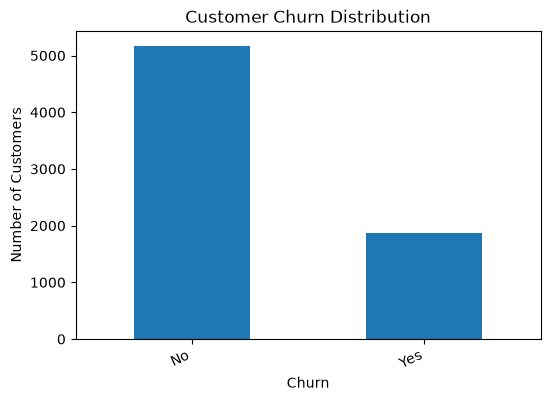

Business insight: Churn is the minority class, so accuracy alone can hide poor detection of churners. Recall and F1 are therefore important.


In [6]:
# 1. Churn distribution
plt.figure(figsize=(6,4))
df[TARGET_COLUMN].value_counts().reindex(["No","Yes"]).plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of Customers")
plt.show()
print("Business insight: Churn is the minority class, so accuracy alone can hide poor detection of churners. Recall and F1 are therefore important.")

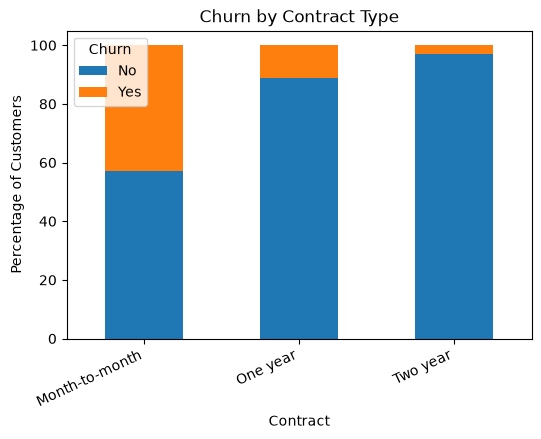

Business insight: Contract type is a strong retention signal because customers with shorter commitments generally have a lower switching barrier.


In [7]:
# 2. Contract vs churn
contract_rate = pd.crosstab(df["Contract"], df["Churn"], normalize="index")*100
contract_rate.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("Churn by Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=25, ha="right")
plt.legend(title=TARGET_COLUMN)
plt.show()
print("Business insight: Contract type is a strong retention signal because customers with shorter commitments generally have a lower switching barrier.")

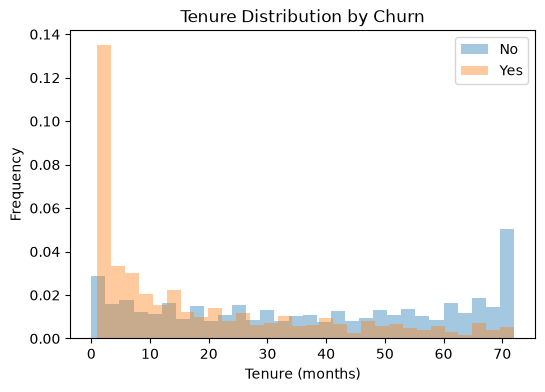

Business insight: Early-tenure behaviour is especially relevant because new customers have had less time to form a relationship with the provider.


In [8]:
# 3. Tenure distribution by churn
plt.figure(figsize=(6,4))
df.loc[df[TARGET_COLUMN]=="No", "tenure"].plot(kind="hist", bins=30, alpha=0.4, density=True, label="No")
df.loc[df[TARGET_COLUMN]=="Yes", "tenure"].plot(kind="hist", bins=30, alpha=0.4, density=True, label="Yes")
plt.legend()
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.show()
print("Business insight: Early-tenure behaviour is especially relevant because new customers have had less time to form a relationship with the provider.")

<Figure size 600x400 with 0 Axes>

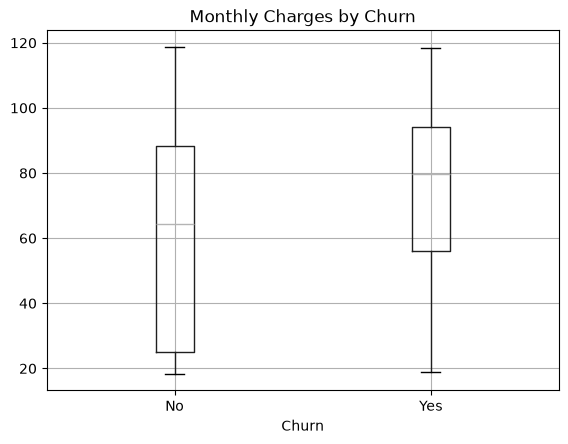

Business insight: Differences in monthly charges can indicate whether price/value perception is related to churn risk.


In [9]:
# 4. Monthly charges by churn
plt.figure(figsize=(6,4))
df.boxplot(column="MonthlyCharges", by=TARGET_COLUMN)
plt.suptitle("")
plt.title("Monthly Charges by Churn")
plt.show()
print("Business insight: Differences in monthly charges can indicate whether price/value perception is related to churn risk.")

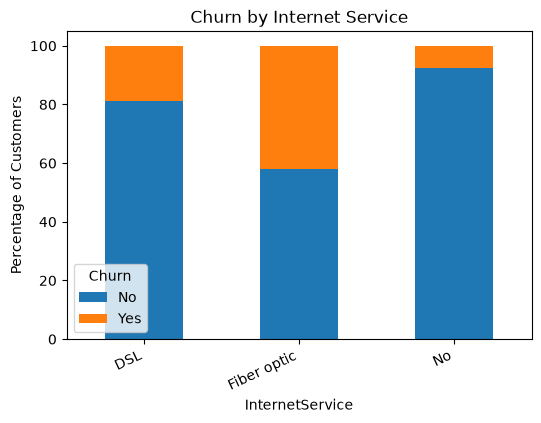

Business insight: Internet service type is useful because the service bundle and customer experience can influence retention.


In [10]:
# 5. Internet service vs churn
internet_rate = pd.crosstab(df["InternetService"], df[TARGET_COLUMN], normalize="index")*100
internet_rate.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("Churn by Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=25, ha="right")
plt.show()
print("Business insight: Internet service type is useful because the service bundle and customer experience can influence retention.")

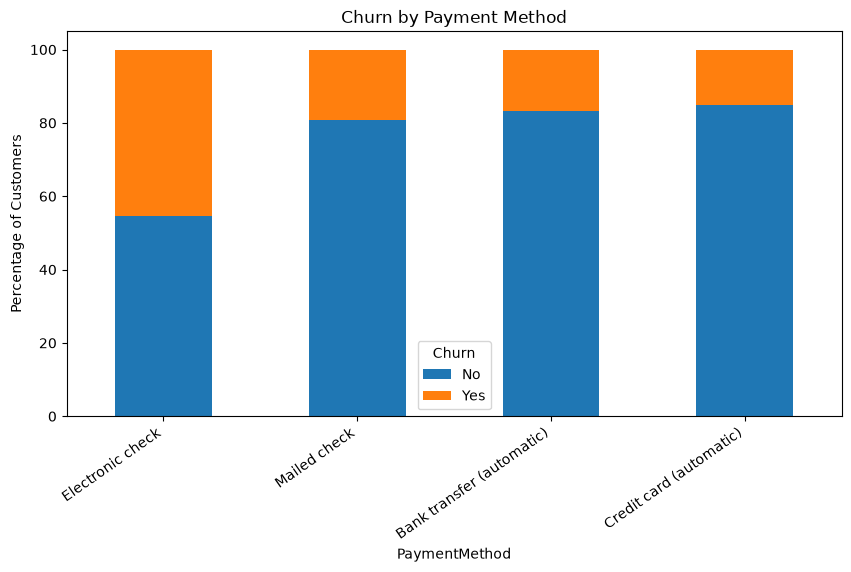

Business insight: Payment method can act as a behavioural/relationship signal and can help the retention team identify segments requiring closer attention.


In [11]:
# 6. Payment method vs churn
payment_rate = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")*100
payment_rate.sort_values("Yes", ascending=False).plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Churn by Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=35, ha="right")
plt.show()
print("Business insight: Payment method can act as a behavioural/relationship signal and can help the retention team identify segments requiring closer attention.")

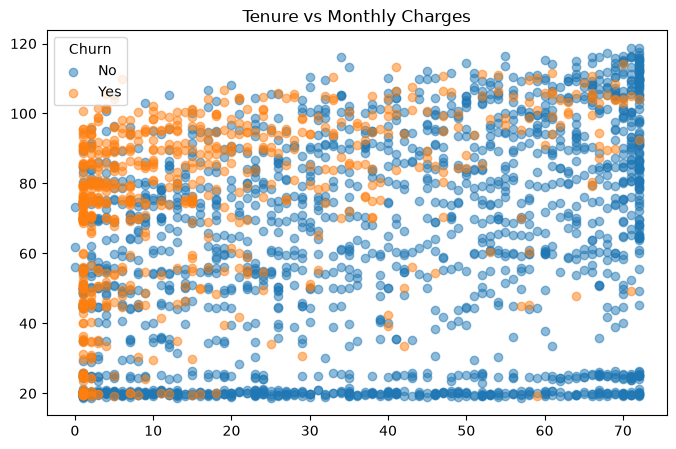

Business insight: Combining tenure and monthly charges gives a more useful view of customer lifecycle and value than either variable alone.


In [12]:
# 7. Tenure and monthly charges relationship
plt.figure(figsize=(8,5))
sample_eda = df.sample(min(2500, len(df)), random_state=42)
for label in ["No", "Yes"]:
    subset = sample_eda[sample_eda["Churn"] == label]
    plt.scatter(subset["tenure"], subset["MonthlyCharges"], alpha=0.5, label=label)
plt.legend(title="Churn")
plt.title("Tenure vs Monthly Charges")
plt.show()
print("Business insight: Combining tenure and monthly charges gives a more useful view of customer lifecycle and value than either variable alone.")

## 6. Feature engineering
Three deterministic, target-independent features. Implemented inside the model pipeline so the exact same transformations are used during training, testing and API inference.

1. **TotalServices** — count of service fields with a `Yes` value. It represents breadth of the customer's relationship with the company.
2. **IsNewCustomer** — 1 when tenure is 12 months or less. It captures early-lifecycle risk.
3. **AvgMonthlySpend** — TotalCharges divided by tenure, with MonthlyCharges used as a safe fallback for zero/unknown tenure. It gives an approximate customer spend level.

In [13]:
fe = CustomerFeatureEngineer()
engineered = fe.fit_transform(X_train)
engineered[["tenure","MonthlyCharges","TotalCharges","TotalServices","IsNewCustomer","AvgMonthlySpend"]].head(10)

,tenure,MonthlyCharges,TotalCharges,TotalServices,IsNewCustomer,AvgMonthlySpend
5557,5,80.20,384.25,2.0,1.0,76.850000
2270,3,86.85,220.95,3.0,1.0,73.650000
6930,3,75.15,216.75,2.0,1.0,72.250000
2257,60,80.55,4847.05,6.0,0.0,80.784167
898,12,98.90,1120.95,5.0,1.0,93.412500
3828,65,19.35,1319.95,1.0,0.0,20.306923
2147,18,19.00,348.80,1.0,0.0,19.377778
3149,8,64.10,504.05,4.0,1.0,63.006250
5401,31,20.45,638.55,1.0,0.0,20.598387
2062,66,25.15,1683.60,2.0,0.0,25.509091


## 7. Model development — Decision Tree configurations
Both baseline models use the same leakage-safe preprocessing. `class_weight="balanced"` gives the minority churn class additional influence and addresses the observed class imbalance.

Two manually specified Decision Tree configurations are compared first so the effect of tree complexity and splitting criterion can be observed before systematic tuning.

In [14]:
configs = {
    "Model_A_Shallow_Gini": {
        "criterion": "gini", "max_depth": 5, "min_samples_leaf": 20, "class_weight": "balanced"
    },
    "Model_B_Entropy_Deeper": {
        "criterion": "entropy", "max_depth": 8, "min_samples_leaf": 10, "class_weight": "balanced"
    },
}

results = []
fitted_models = {}
for name, params in configs.items():
    pipe = build_model_pipeline(params)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, pos_label="Yes"),
        "Recall": recall_score(y_test, pred, pos_label="Yes"),
        "F1": f1_score(y_test, pred, pos_label="Yes"),
    })
    fitted_models[name] = pipe

comparison = pd.DataFrame(results).sort_values(["Recall", "F1"], ascending=False)
display(comparison.style.format({c: "{:.4f}" for c in ["Accuracy","Precision","Recall","F1"]}))
comparison.to_csv(MODEL_DIR / "model_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1
0,Model_A_Shallow_Gini,0.6981,0.4621,0.8360,0.5952
1,Model_B_Entropy_Deeper,0.7071,0.4685,0.7701,0.5826


## 7.1 Bonus — Hyperparameter tuning
The two hand-selected configurations above are useful comparisons, but they are not systematic hyperparameter tuning. To add a stronger bonus component, `GridSearchCV` searches a defined parameter grid using only the training data.

The scoring metric is F1 for the churn class (`Yes`). This balances the business preference for recall with the need to avoid an excessively high false-positive rate. Five-fold stratified cross-validation is used so that each fold preserves the class distribution. The test set remains untouched during tuning and is used only for final evaluation.

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    make_scorer
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# Systematic Decision Tree tuning using training data only
f1_churn_scorer = make_scorer(f1_score, pos_label="Yes")

tuning_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7, 10],
    "classifier__min_samples_leaf": [5, 10, 20, 30],
    "classifier__class_weight": ["balanced"],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=build_model_pipeline({}),
    param_grid=tuning_grid,
    scoring=f1_churn_scorer,
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)
grid_search.fit(X_train, y_train)

tuned_tree = grid_search.best_estimator_
print("Best Decision Tree parameters:")
print(grid_search.best_params_)
print(f"Best mean cross-validated F1: {grid_search.best_score_:.4f}")

tuned_pred = tuned_tree.predict(X_test)
tuned_result = {
    "Model": "Tuned_Decision_Tree",
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred, pos_label="Yes"),
    "Recall": recall_score(y_test, tuned_pred, pos_label="Yes"),
    "F1": f1_score(y_test, tuned_pred, pos_label="Yes"),
}

display(pd.DataFrame([tuned_result]).round(4))


Best Decision Tree parameters:
{'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 30}
Best mean cross-validated F1: 0.6080


,Model,Accuracy,Precision,Recall,F1
0,Tuned_Decision_Tree,0.7402,0.5068,0.7914,0.618


## 7.2 Bonus — Comparing additional model types
As an additional benchmark, Logistic Regression and Random Forest are evaluated using the same feature engineering and preprocessing strategy. This is useful because it shows whether the required Decision Tree is competitive with different modelling assumptions.

The comparison is performed on the same held-out test set. The additional models are benchmarks rather than replacements for the required Decision Tree.

In [16]:
from pathlib import Path
import sys
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

current_path = Path.cwd()

if (current_path / "src" / "model_utils.py").exists():
    PROJECT_ROOT = current_path
elif (current_path.parent / "src" / "model_utils.py").exists():
    PROJECT_ROOT = current_path.parent
else:
    raise FileNotFoundError(
        "Could not find src/model_utils.py. "
        "Make sure the notebook is inside the Assignment 1 project."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model_utils import CustomerFeatureEngineer, build_preprocessor

def build_general_pipeline(classifier):
    return Pipeline([
        ("features", CustomerFeatureEngineer()),
        ("preprocess", build_preprocessor()),
        ("classifier", classifier),
    ])

benchmark_models = {
    "Tuned_Decision_Tree": tuned_tree,
    "Logistic_Regression": build_general_pipeline(
        LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            class_weight="balanced",
            random_state=42,
        )
    ),
    "Random_Forest": build_general_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
    ),
}

benchmark_results = []

for name, model in benchmark_models.items():
    if name != "Tuned_Decision_Tree":
        model.fit(X_train, y_train)

    pred = model.predict(X_test)

    benchmark_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, pos_label="Yes"),
        "Recall": recall_score(y_test, pred, pos_label="Yes"),
        "F1": f1_score(y_test, pred, pos_label="Yes"),
    })

model_comparison = (pd.DataFrame(benchmark_results).sort_values(["Recall", "F1"], ascending=False).reset_index(drop=True))

display(model_comparison.round(4))

MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_comparison.to_csv(MODEL_DIR / "model_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1
0,Random_Forest,0.7605,0.5325,0.8039,0.6406
1,Tuned_Decision_Tree,0.7402,0.5068,0.7914,0.6180
2,Logistic_Regression,0.7392,0.5057,0.7897,0.6166


### Model selection
For this use case, a false negative means a customer who is likely to churn is not flagged for retention. That can be more costly than contacting a customer who ultimately stays. Therefore recall is prioritized, with F1 and precision used as guardrails against an overly aggressive model. The selected model is the one with the strongest recall/F1 balance among the required Decision Tree configurations.

In [17]:
selected_name = comparison.iloc[0]["Model"]
final_model = fitted_models[selected_name]
print("Selected model:", selected_name)
print("Parameters:", configs[selected_name])

Selected model: Model_A_Shallow_Gini
Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'class_weight': 'balanced'}


## 8. Final model evaluation
The following metrics satisfy the assignment requirements and are interpreted from the perspective of a telecom retention team.

In [18]:
final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, list(final_model.named_steps["classifier"].classes_).index("Yes")]

metrics = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, pos_label="Yes"),
    "Recall": recall_score(y_test, final_pred, pos_label="Yes"),
    "F1 Score": f1_score(y_test, final_pred, pos_label="Yes"),
}


final_pred = final_model.predict(X_test)

final_proba = final_model.predict_proba(X_test)[:, list(final_model.named_steps["classifier"].classes_).index("Yes")]

metrics = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, pos_label="Yes"),
    "Recall": recall_score(y_test, final_pred, pos_label="Yes"),
    "F1 Score": f1_score(y_test, final_pred, pos_label="Yes"),
}

display(pd.DataFrame([metrics]).T.rename(columns={0: "Score"}).round(4))
print(classification_report(y_test, final_pred, target_names=["No churn", "Churn"]))
print(classification_report(y_test, final_pred, target_names=["No churn", "Churn"]))

,Score
Accuracy,0.6981
Precision,0.4621
Recall,0.8360
F1 Score,0.5952


              precision    recall  f1-score   support

    No churn       0.92      0.65      0.76      1552
       Churn       0.46      0.84      0.60       561

    accuracy                           0.70      2113
   macro avg       0.69      0.74      0.68      2113
weighted avg       0.80      0.70      0.72      2113

              precision    recall  f1-score   support

    No churn       0.92      0.65      0.76      1552
       Churn       0.46      0.84      0.60       561

    accuracy                           0.70      2113
   macro avg       0.69      0.74      0.68      2113
weighted avg       0.80      0.70      0.72      2113



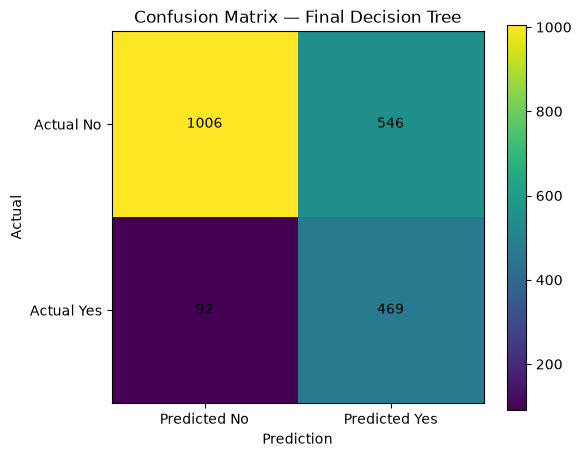

Business interpretation: False negatives are actual churners that the retention team would miss; false positives are customers contacted even though they did not churn.


In [19]:
cm = confusion_matrix(y_test, final_pred, labels=["No", "Yes"])
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.colorbar()
plt.xticks([0,1],["Predicted No","Predicted Yes"])
plt.yticks([0,1],["Actual No","Actual Yes"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.title("Confusion Matrix — Final Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Prediction")
plt.show()
print("Business interpretation: False negatives are actual churners that the retention team would miss; false positives are customers contacted even though they did not churn.")

### Precision vs Recall decision
**Recall should generally be prioritized** for proactive retention because missing a real churner directly removes that customer from the intervention pool. Precision still matters because retention budgets are finite, but the cost of a false negative can be higher than the cost of a false positive.

## 9. Model interpretation
Decision Trees are interpretable because each prediction is produced through feature-based splits. After one-hot encoding, categorical variables appear as separate transformed features such as `Contract_Month-to-month` or `PaymentMethod_Electronic check`.

,Feature,Importance
39,Contract_Month-to-month,0.609524
1,tenure,0.111951
19,InternetService_Fiber optic,0.101508
2,MonthlyCharges,0.046386
3,TotalCharges,0.030877
21,OnlineSecurity_No,0.018579
20,InternetService_No,0.016507
6,AvgMonthlySpend,0.015190
30,TechSupport_No,0.014785
46,PaymentMethod_Electronic check,0.014336


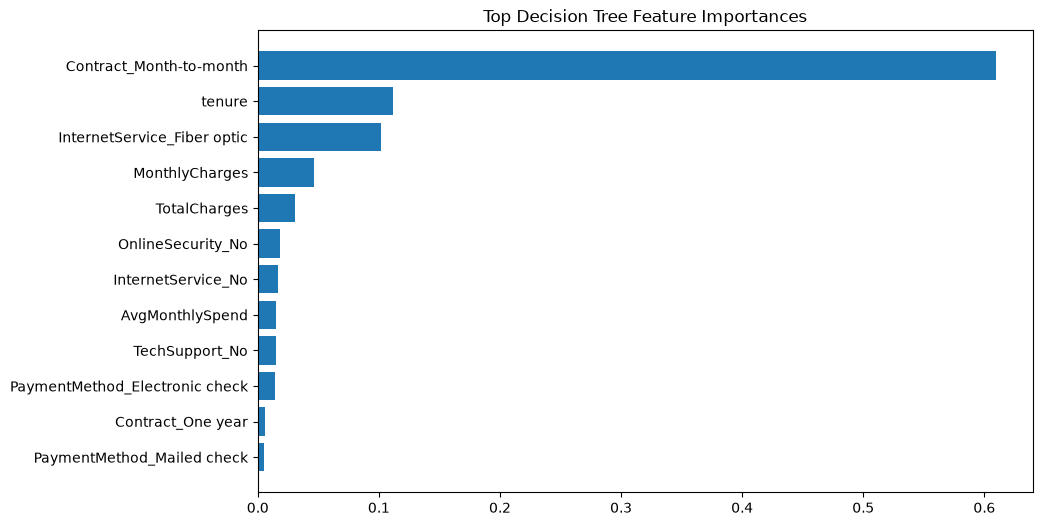

In [20]:
feature_names = transformed_feature_names(final_model)
importances = final_model.named_steps["classifier"].feature_importances_
fi = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values("Importance", ascending=False)
display(fi.head(15))
fi.to_csv(MODEL_DIR / "feature_importance.csv", index=False)

plt.figure(figsize=(10,6))
top_fi = fi.head(12).sort_values("Importance")
plt.barh(top_fi["Feature"], top_fi["Importance"])
plt.title("Top Decision Tree Feature Importances")
plt.show()

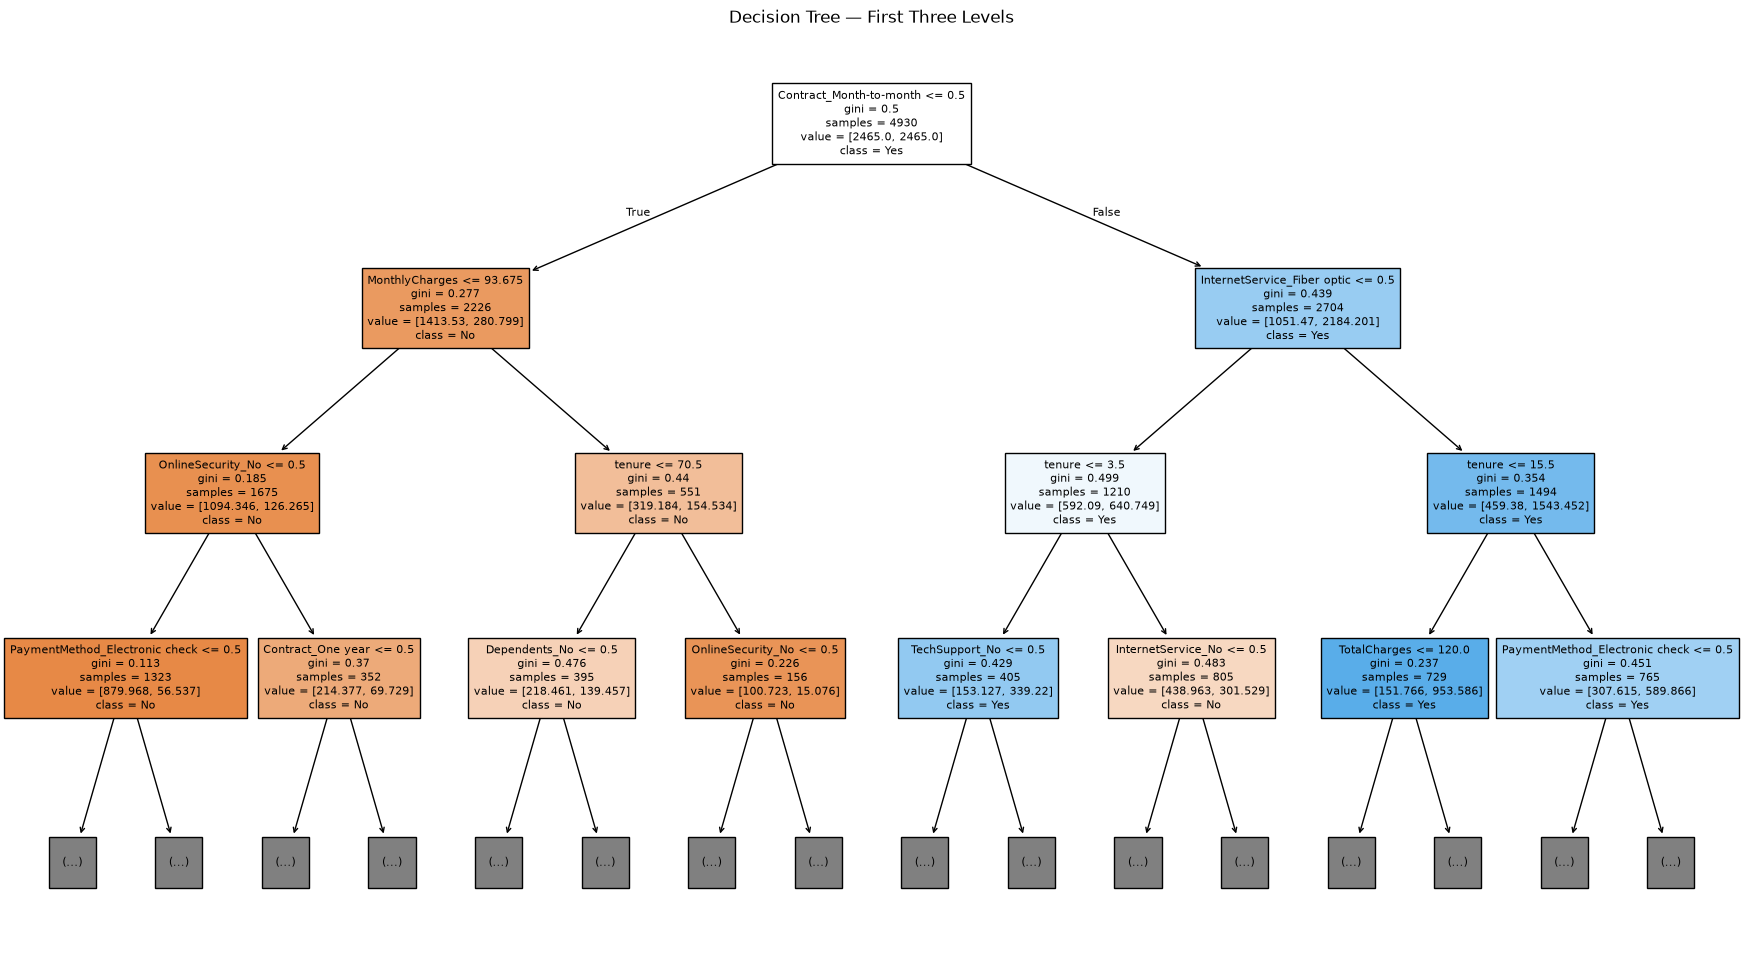

In [21]:
plt.figure(figsize=(22,12))
plot_tree(
    final_model.named_steps["classifier"],
    feature_names=feature_names,
    class_names=final_model.named_steps["classifier"].classes_,
    max_depth=3, filled=True, fontsize=8
)
plt.title("Decision Tree — First Three Levels")
plt.savefig(MODEL_DIR / "decision_tree.png", dpi=180, bbox_inches="tight")
plt.show()

## 10. Save the complete preprocessing + model pipeline
The saved artifact contains feature engineering, imputation, one-hot encoding and the Decision Tree. Saving them together prevents training/inference preprocessing drift.

In [22]:
joblib.dump(final_model, MODEL_DIR / "churn_model.pkl")
print("Saved:", MODEL_DIR / "churn_model.pkl")
print("Saved comparison:", MODEL_DIR / "model_comparison.csv")
print("Saved feature importance:", MODEL_DIR / "feature_importance.csv")
print("Saved tree image:", MODEL_DIR / "decision_tree.png")

Saved: C:\NAGP\Assignments\DS\assignment_1_customer_churn\model\churn_model.pkl
Saved comparison: C:\NAGP\Assignments\DS\assignment_1_customer_churn\model\model_comparison.csv
Saved feature importance: C:\NAGP\Assignments\DS\assignment_1_customer_churn\model\feature_importance.csv
Saved tree image: C:\NAGP\Assignments\DS\assignment_1_customer_churn\model\decision_tree.png


## 11. API smoke test in Python
The Flask API is implemented in `app.py`. It accepts the same raw customer fields used by the pipeline, so preprocessing remains centralized in the saved model.

In [23]:
sample_request = json.loads((ROOT / "sample_request.json").read_text())
sample_df = pd.DataFrame([sample_request])
sample_prediction = final_model.predict(sample_df)[0]
sample_prob = final_model.predict_proba(sample_df)[0][list(final_model.named_steps["classifier"].classes_).index("Yes")]
print({"prediction": str(sample_prediction), "churn_probability": round(float(sample_prob), 4)})

{'prediction': 'Yes', 'churn_probability': 0.7669}
